In [1]:
import time, sys, os, glob

import numpy as np
import matplotlib.pyplot as plt

from src.DE_simulation import DE_simulation
from src.ABM_package import ABM_simulation
from src.custom_functions import get_parameters_files

In [2]:
# ==========================================
# Run the PDE 1,000 times and record the walltimes
# ==========================================

#Model 4 (rm_pint_rp_a0_a1)
parameter_names = "rm_pint_rp_a0_a1"
model_type = "PDE"
data_type = "artificial"
simulation = 7
pred_type = "fit_all"

input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

(parameter_names, 
    model_type, 
    data_type, 
    dens, 
    simulation,
    initial_perc,
    trueParams,
    delay, 
    lower_bounds,
    upper_bounds,
    indepParams,
    dxs,
    prediction_type,
    priorDir, 
    histogramDir, 
    posteriorDir) = get_parameters_files(input_parameters)

numParams = 1000

### Sample the parameters uniformly
rms = np.random.uniform(low  = lower_bounds[0], 
                        high = upper_bounds[0], 
                        size = (numParams,1))
ppulls = np.random.uniform(low  = lower_bounds[1], 
                        high = upper_bounds[1], 
                        size = (numParams,1))      
rps = np.random.uniform(low  = lower_bounds[2], 
                        high = upper_bounds[2], 
                        size = (numParams,1))
a0s = np.random.uniform(low  = lower_bounds[3], 
                        high = upper_bounds[3], 
                        size = (numParams,1))
a1s = np.random.uniform(low  = lower_bounds[4], 
                        high = upper_bounds[4], 
                        size = (numParams,1))

#combine all samples into one large matrix
ps = np.hstack([rms, 
                 ppulls,
                 rps,
                 a0s,
                 a1s])

#Record all PDE times
DE_times = []
for p in ps:
    
    time0 = time.time()
    
    DE_simulation(p,
                  data_type,
                  dens=dens,
                  simulation=simulation,
                  delay=delay)
    
    time_elapsed = time.time() - time0
    
    DE_times.append(time_elapsed)
    
DE_times = np.array(DE_times)

In [3]:
# ==========================================
# Load in 1,000 pre-computed ABM walltimes
# ==========================================
ABM_times = []

for file in glob.glob("../../results/timing/*"):

    mat = np.load(file,allow_pickle=True).item()
    
    ABM_times.append(mat["time_elapsed"])
    
ABM_times = np.array(ABM_times)

ABM_times.shape

(1000,)

In [4]:
print(f"  Mean PDE time: {np.mean(DE_times):.4f} seconds")
print(f"Median PDE time: {np.median(DE_times):.4f} seconds")

print(f"\n  Mean ABM time: {np.mean(ABM_times):.4f} seconds")
print(f"Median ABM time: {np.median(ABM_times):.4f} seconds")

print(f"\n ABM-PDE mean ratio: {np.mean(ABM_times)/np.mean(DE_times):.1f}")

  Mean PDE time: 0.0274 seconds
Median PDE time: 0.0277 seconds

  Mean ABM time: 82.7572 seconds
Median ABM time: 37.0134 seconds

 ABM-PDE mean ratio: 3019.8


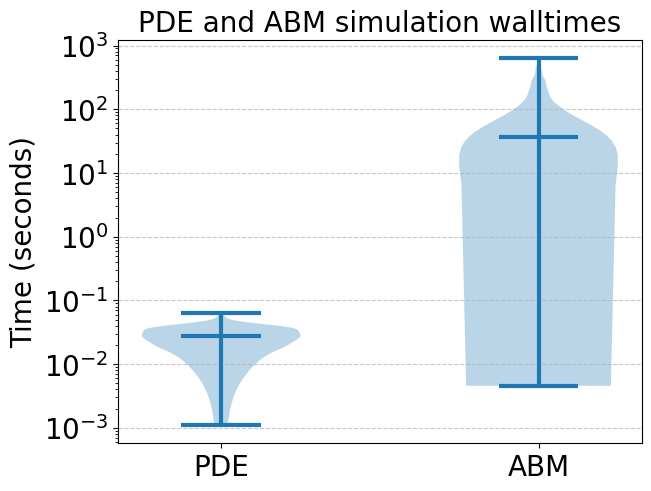

In [18]:
# ==========================================
# Compute box plots
# ==========================================

plt.figure(layout="constrained")

parts = plt.violinplot([DE_times, ABM_times], 
               positions=[1, 2], 
               showmedians=True)

for partname in ['cmaxes', 'cmins', 'cbars', 'cmedians']:
    vp = parts[partname]
    vp.set_linewidth(3.0)  # Increase the thickness here
    #vp.set_edgecolor('black')

fontsize = 20

plt.xticks([1, 2], ['PDE', 'ABM'],fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title("PDE and ABM simulation walltimes",fontsize=fontsize)
plt.ylabel("Time (seconds)",fontsize=fontsize)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.yscale('log')

plt.savefig("../../results/Figures/Simulation_times.pdf")

In [6]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Mon Jun 08 2026

Python implementation: CPython
Python version       : 3.11.5
IPython version      : 8.15.0

numpy     : 1.25.2
matplotlib: 3.8.0
sys       : 3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]

Watermark: 2.4.3

